# Tutorial: Seurat → kopya → Seurat

Annotate cell types once in **Seurat**, run **kopya** to call copy-number and
separate tumor from normal, then bring the calls back into your Seurat object to sharpen
those annotations.

kopya works in memory on an [AnnData](https://anndata.readthedocs.io/) object — the same
object scanpy and infercnvpy use — so the only R↔Python step is a one-time export/import.

> **How this notebook is run.** The R/Seurat cells are shown as code you run in
> R/RStudio (they need Seurat + your data). The **Python kopya cells below are
> executed on a real annotated lung-cancer dataset** so you can preview the actual
> output — including the CNV heatmap — without running anything.

> **To run the Python cells yourself:** `pip install -e ".[plot]" infercnvpy` — the tutorial pulls its example dataset (`maynard2020_3k`) through infercnvpy, and the heatmap needs the `[plot]` extra. infercnvpy is only needed for this demo data, not by kopya itself.

## 1. Seurat: load, QC, and one annotation pass  *(run in R)*

Your normal Seurat workflow, run once to get cell-type labels. The goal is only to
identify a **confident normal reference** (immune + stromal lineages); you do *not* need
to know yet which epithelial cells are tumor — that's what kopya tells you.

```r
library(Seurat)
seu <- Read10X("filtered_feature_bc_matrix/") |>
  CreateSeuratObject(min.cells = 3, min.features = 200)

seu[["percent.mt"]] <- PercentageFeatureSet(seu, pattern = "^MT-")
seu <- subset(seu, subset = nFeature_RNA > 200 & percent.mt < 20)
seu <- NormalizeData(seu) |> FindVariableFeatures() |> ScaleData() |> RunPCA()
seu <- FindNeighbors(seu, dims = 1:30) |> FindClusters(resolution = 0.5) |> RunUMAP(dims = 1:30)

# label clusters by canonical markers (SingleR works too)
FeaturePlot(seu, c("PTPRC","CD3E","CD68","PECAM1","COL1A1","EPCAM"))
seu$cell_type <- plyr::mapvalues(Idents(seu), from = levels(Idents(seu)),
  to = c("T cell","Macrophage","Epithelial","Endothelial","Fibroblast","T cell","B cell","Epithelial"))
```

## 2. Export to h5ad  *(run in R)*

kopya needs **raw counts**. The most reliable export is `sceasy` with
`main_layer = "counts"`, which writes the raw `counts` slot straight to
`adata.X` — so on the Python side you just use the default (`layer=None`):

```r
library(sceasy)
sceasy::convertFormat(seu, from = "seurat", to = "anndata",
                      assay = "RNA", main_layer = "counts",
                      outFile = "sample.h5ad")
```

> **Watch the counts.** However you export, confirm raw counts landed where you
> read them: `print(adata.X[:5,:5].toarray())` should show integers, not
> log-values. With SeuratDisk (`SaveH5Seurat` + `Convert`) the slot mapping
> depends on the assay/version — `counts` may land in a layer, `raw`, or not at
> all after `ScaleData()` — so check `adata.layers.keys()` and point kopya at
> the right place (`layer="counts"` if that's where they are).

## 3. Run kopya  *(Python — executed below)*

For a runnable example we load **maynard2020_3k** — an annotated lung-adenocarcinoma
AnnData, the kind of object your Seurat export produces (it has an `Epithelial cell`
tumor population and immune/stromal lineages). It ships log-normalized, so we de-log it to
pseudo-counts; **your Seurat export already has raw counts, so you'd skip that line.**

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")   # keep the preview clean
import numpy as np, scipy.sparse as sp
import anndata as ad
import kopya as kp

# --- load an annotated example (stand-in for your Seurat export) ---
import infercnvpy as cnv
src = cnv.datasets.maynard2020_3k()                 # log-normalized + obs['cell_type']
X = (src.X.toarray() if sp.issparse(src.X) else np.asarray(src.X)).astype(np.float32)
counts = np.expm1(X)                                 # de-log -> pseudo-counts (float32)
adata = ad.AnnData(X=sp.csr_matrix(np.clip(counts, 0, None)),
                   obs=src.obs[['cell_type']].copy(), var=src.var[[]].copy())
adata.var_names_make_unique()
print(adata)
adata.obs['cell_type'].value_counts()

AnnData object with n_obs × n_vars = 3000 × 55556
    obs: 'cell_type'


cell_type
Epithelial cell         522
Macrophage              409
Fibroblast              308
T cell CD4              259
T cell CD8              246
Monocyte                227
Endothelial cell        148
Plasma cell             139
other                   115
mDC                     106
B cell                   83
Mast cell                79
Alevolar cell type 2     65
T cell regulatory        54
NK cell                  52
Smooth muscle cell       45
Pericyte                 34
pDC                      33
Ciliated                 29
Alevolar cell type 1     26
T cell dividing          21
Name: count, dtype: int64

Run supervised: the immune/stromal lineages are the normal reference. Results are written
back onto the AnnData, scanpy-style.

In [2]:
immune = ["T cell CD4","T cell CD8","T cell regulatory","B cell","NK cell",
          "Macrophage","Monocyte","Mast cell","Plasma cell","mDC","pDC"]

# maynard's de-logged pseudo-counts aren't integers, so we pass raw_count_check="ignore".
# A real Seurat export has raw counts, so you'd drop it (the default "warn" then stays quiet).
kp.tl.cnv(adata, reference_key="cell_type", reference_cat=immune, raw_count_check="ignore")
# (raw counts in a layer instead of X? kp.tl.cnv(adata, ..., layer="counts"))

print("baseline:", adata.uns['cnv']['baseline_method'])
adata.obs['cnv_class'].value_counts(dropna=False)

baseline: supervised


cnv_class
normal       2465
tumor         496
uncertain      39
Name: count, dtype: int64

`tl.cnv` populated the AnnData:

| where | what |
|---|---|
| `obs['cnv_class']` | `tumor` / `normal` / `uncertain` (`NaN` = QC-filtered) |
| `obs['cnv_score']` | per-cell aneuploidy score |
| `obs['cnv_subclone']` | subclone label within tumor cells |
| `obsm['cnv_chr']` | cells × chromosomes, 1.0-centered (>1 gain, <1 loss) |
| `uns['cnv']` | chromosomes, baseline method, params, segment table |

In [3]:
[c for c in adata.obs.columns if c.startswith('cnv')], list(adata.obsm), list(adata.uns['cnv'])

(['cnv_class', 'cnv_score', 'cnv_subclone', 'cnv_low_complexity'],
 ['cnv_chr'],
 ['chroms',
  'baseline_method',
  'n_tumor',
  'n_normal',
  'n_uncertain',
  'n_segments',
  'n_cells_filtered',
  'params',
  'segments'])

### Heatmap: references flat, tumor lit up

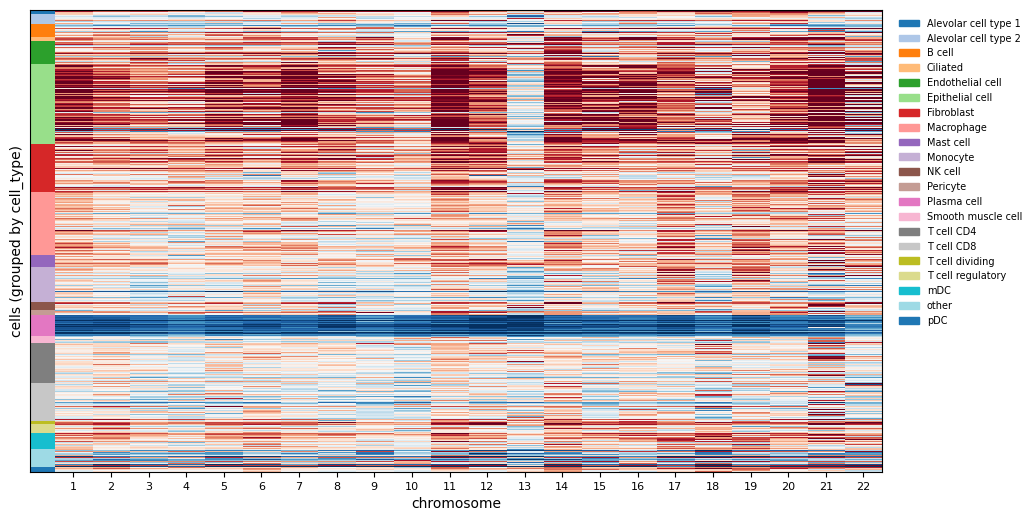

In [4]:
kp.pl.chromosome_heatmap(adata, groupby="cell_type");

Which cell types did kopya call tumor? The malignant `Epithelial cell` cluster lights
up; immune/stroma stay normal.

In [5]:
import pandas as pd
pd.crosstab(adata.obs['cell_type'], adata.obs['cnv_class'])

cnv_class,normal,tumor,uncertain
cell_type,,,
Alevolar cell type 1,20,6,0
Alevolar cell type 2,63,2,0
B cell,83,0,0
Ciliated,12,17,0
Endothelial cell,117,31,0
Epithelial cell,183,337,2
Fibroblast,243,64,1
Macrophage,409,0,0
Mast cell,79,0,0


> **Mesenchymal tumors.** If your tumor *is* the stromal lineage (sarcoma, e.g. of bone or soft tissue),
> do **not** put Fibroblast/Osteoblast in `reference_cat` — the tumor would seed its own
> reference and the call inverts. Use immune cells only.

## 4. Bring the calls back into Seurat  *(run in R)*

Write the per-cell calls out (`adata.obs[['cnv_class','cnv_score','cnv_subclone']].to_csv("cnv_calls.csv")`),
then in R:

```r
cnv <- read.csv("cnv_calls.csv", row.names = 1)
seu <- AddMetaData(seu, cnv)

DimPlot(seu, group.by = "cnv_class")        # tumor vs normal on your UMAP
FeaturePlot(seu, "cnv_score")               # aneuploidy load
table(seu$cell_type, seu$cnv_class)         # which 'Epithelial' cells are malignant?

seu$cell_type_refined <- ifelse(
  seu$cell_type == "Epithelial" & seu$cnv_class == "tumor",
  "Tumor (malignant epithelial)", as.character(seu$cell_type))
DimPlot(seu, group.by = "cell_type_refined")
```

You now have CNV-backed tumor/normal calls layered onto the annotations you started
with — the "go back to the annotations" step.

## Pure-scanpy quickstart (no Seurat)

Already in Python? Skip the R steps:

```python
import scanpy as sc, kopya as kp
adata = sc.read_10x_h5("filtered_feature_bc_matrix.h5")   # raw counts in .X
# ... your annotation pass populates adata.obs['cell_type'] ...
kp.tl.cnv(adata, reference_key="cell_type",
          reference_cat=["T cell","B cell","Macrophage","Endothelial"])
kp.pl.chromosome_heatmap(adata, groupby="cell_type")
```

Fully unsupervised is just `kp.tl.cnv(adata)`.

**Notes.** Raw counts are required (kopya does its own CP10k+log1p). chrX/chrY are
excluded (autosome-only). For ~1M-cell cohorts the CLI has a memory-lean path
(`kopya run --anndata sample.h5ad --out-dir out/`); for the per-segment,
genome-position heatmap use `kopya plot-heatmap --run-dir out/`.